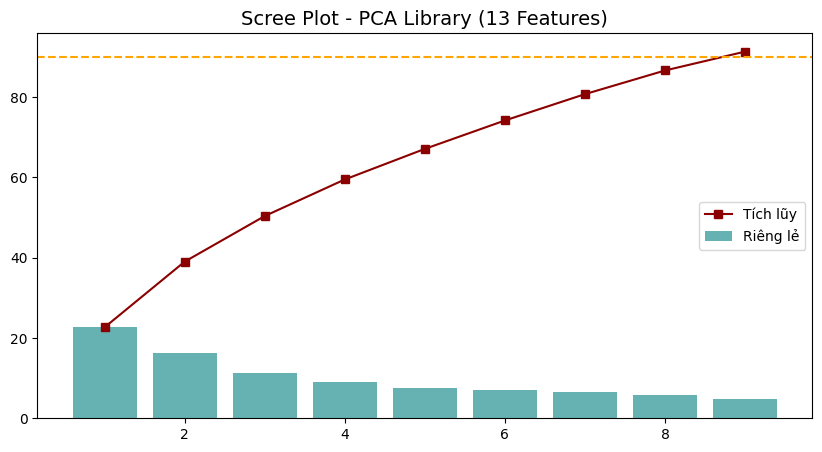


--- BẢNG LOADING MATRIX (9 PCs) ---


,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9
co,-0.103,0.260,-0.240,-0.508,0.000,-0.387,0.251,0.219,0.568
no2,-0.303,-0.025,-0.259,0.068,-0.007,0.279,0.529,0.492,-0.399
o3,0.328,-0.387,0.088,0.182,0.093,-0.151,-0.125,0.096,0.143
pm10,-0.359,-0.293,-0.326,-0.031,0.310,-0.007,-0.332,0.037,0.067
pm25,-0.386,-0.324,-0.295,-0.016,0.241,-0.004,-0.247,-0.054,0.057
so2,-0.083,-0.323,-0.009,0.571,-0.253,0.007,0.299,0.114,0.540
clouds,-0.153,0.171,0.429,0.226,0.171,-0.367,-0.238,0.617,-0.061
precipitation,0.057,0.187,0.001,0.293,0.739,-0.202,0.426,-0.324,-0.009
pressure,-0.373,-0.245,0.443,-0.195,-0.075,-0.092,0.182,-0.201,-0.033
relative_humidity,-0.179,0.477,-0.107,0.292,0.018,0.060,-0.319,0.043,0.060



Top features đóng góp từng PC:
  PC1 (22.7% phương sai): temperature (+0.45), pm25 (-0.39), pressure (-0.37)
  PC2 (16.4% phương sai): relative_humidity (+0.48), o3 (-0.39), uv_index (-0.36)
  PC3 (11.4% phương sai): pressure (+0.44), temperature (-0.43), clouds (+0.43)
  PC4 (9.1% phương sai): so2 (+0.57), co (-0.51), precipitation (+0.29)
  PC5 (7.6% phương sai): precipitation (+0.74), wind_speed (+0.41), pm10 (+0.31)
  PC6 (7.1% phương sai): wind_speed (+0.66), co (-0.39), clouds (-0.37)
  PC7 (6.6% phương sai): no2 (+0.53), precipitation (+0.43), pm10 (-0.33)
  PC8 (5.9% phương sai): clouds (+0.62), no2 (+0.49), precipitation (-0.32)
  PC9 (4.7% phương sai): co (+0.57), so2 (+0.54), no2 (-0.40)


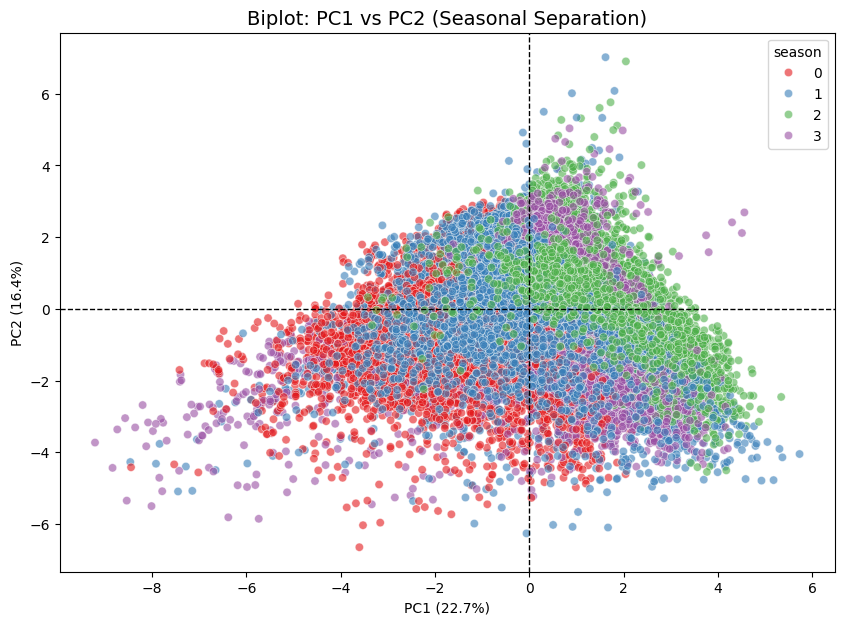

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# 1. Đọc dữ liệu
df = pd.read_csv('../clean/hanoi_aqi_cleaned.csv')

# 2. Lọc đúng 13 cột khí tượng
target_cols = ['co', 'no2', 'o3', 'pm10', 'pm25', 'so2', 'clouds', 
               'precipitation', 'pressure', 'relative_humidity', 
               'temperature', 'uv_index', 'wind_speed']
df.columns = df.columns.str.strip().str.lower()
cols_found = [c for c in df.columns if c in target_cols]

# --- THAY ĐỔI THEO YÊU CẦU PHƯƠNG ANH ---
X = df[cols_found]
# Vì PCA không nhận giá trị rỗng, mình xử lý nhanh bằng cách điền giá trị trung bình (median)
X = X.apply(pd.to_numeric, errors='coerce').fillna(X.median(numeric_only=True))

# 3. Chuẩn hóa và chạy PCA (Lấy 9 thành phần chính)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA(n_components=9)
X_pca = pca.fit_transform(X_scaled)

# --- SCREE PLOT ---
plt.figure(figsize=(10, 5))
exp_var = pca.explained_variance_ratio_ * 100
plt.bar(range(1, 10), exp_var, alpha=0.6, color='teal', label='Riêng lẻ')
plt.plot(range(1, 10), np.cumsum(exp_var), marker='s', color='darkred', label='Tích lũy')
plt.axhline(y=90, color='orange', linestyle='--')
plt.title('Scree Plot - PCA Library (13 Features)', fontsize=14)
plt.legend()
plt.show()

# --- LOADING MATRIX & GIẢI THÍCH TỪNG PC (PHƯƠNG ANH) ---
loadings = pd.DataFrame(
    pca.components_.T,
    index=cols_found,
    columns=[f'PC{i+1}' for i in range(9)]
).round(3)

print("\n--- BẢNG LOADING MATRIX (9 PCs) ---")
display(loadings)

print("\nTop features đóng góp từng PC:")
for i in range(9):
    pc = f'PC{i+1}'
    # Tìm 3 tính năng có ảnh hưởng lớn nhất (giá trị tuyệt đối cao nhất)
    top = loadings[pc].abs().nlargest(3).index.tolist()
    vals = [f"{f} ({loadings[pc][f]:+.2f})" for f in top]
    print(f"  {pc} ({exp_var[i]:.1f}% phương sai): {', '.join(vals)}")

# --- BIPLOT (Tô màu theo mùa) ---
plt.figure(figsize=(10, 7))
# X.index bây giờ khớp hoàn toàn với df.index vì không còn dropna
sns.scatterplot(x=X_pca[:, 0], y=X_pca[:, 1], hue=df.loc[X.index, 'season'], palette='Set1', alpha=0.6)
plt.title('Biplot: PC1 vs PC2 (Seasonal Separation)', fontsize=14)
plt.xlabel(f'PC1 ({exp_var[0]:.1f}%)')
plt.ylabel(f'PC2 ({exp_var[1]:.1f}%)')
plt.axhline(0, color='black', linestyle='--', linewidth=1)
plt.axvline(0, color='black', linestyle='--', linewidth=1)
plt.show()